# Project Final Report

### Due: 11:59pm on August 9th (with a two hour + one minute grace period) — 50 points  

### No late submissions will be accepted.


Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include code, code screenshots, or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation. 
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer in this cell--do not add additional cells" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.




## Submission Checklist

- Final Report Notebook — submitted by team leader  
- **DO NOT SUBMIT Word or PDF files!**



## 1. Executive Summary [4 points]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why. 

**1.1 Answer:**  

This project examined whether property information could be used to estimate assessed tax value and help a real estate company better understand what affects property values. We used a large Zillow housing dataset with information about property size, location, age, land use, building quality, rooms, and other features. The goal was not only to make predictions, but also to find useful patterns that could support property-value and market analysis.

The data included several challenges. Many columns had missing information, some features provided similar information, and a small number of properties had very high values or unusual measurements. These issues had to be handled carefully so that the results would be more reliable. Our analysis showed that property size was strongly connected to assessed value. Finished living area was one of the clearest indicators. The number of bathrooms and bedrooms, lot size, building quality, and location also provided useful information. We also found that some new features that seemed useful at first did not improve the final predictions when we tested them.

After comparing several approaches, we selected the model that produced the lowest average error. On the final test group, its predictions differed from the actual assessed values by about $185,580 per property on average. The result was very close to the model’s performance during development. This suggests that the model gave consistent results when it was tested on properties that were not used to build it. However, the size of the average error also shows that predicting the exact value of an individual property remains difficult.

We recommend using this model as an internal support tool rather than as the only basis for property decisions. It can help the company understand general value patterns, compare groups of properties, and support market analysis. However, individual estimates should still be reviewed by people with knowledge of the property and local market. Future work may improve the predictions by adding more detailed information about property condition, renovations, and local neighborhoods.


## 2. Introduction [3 points]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  

This project focuses on predicting the assessed tax value of properties using the Zillow housing dataset. The dataset includes information about each property, such as its size, location, age, number of rooms, lot size, and building features. In a real estate setting, this information can help professionals better understand the factors connected to property value.

The main problem is that property values depend on many factors, and the relationship between these factors is not always simple. Properties with similar sizes may have very different values because of their location, age, quality, or other features. The data also contains missing information and unusual values, which can make accurate predictions more difficult. Finding a reliable way to estimate assessed value is important because it can help real estate professionals compare properties more consistently, understand market patterns, and make better-informed decisions.

The main objective of this analysis was to build a regression model that could estimate assessed tax value for new properties. To reach this goal, we examined and prepared the data, identified useful property features, and tested different ways to improve the information used by the models. We also compared several regression models and improved the strongest ones. The final goal was to select a model that could provide useful and consistent estimates when applied to property data it had not seen before.


## 3. Data Description [3 points]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  

The dataset used in this project is a reduced version of the Zillow housing dataset from the 2017 Zillow Prize competition on Kaggle. The reduced dataset was provided through the course download link.

The raw dataset contained 77,613 property records and 55 columns. One column was the target variable, so the dataset had 54 possible input features. These features described different parts of a property, including its living area, lot size, location, age, number of rooms, building quality, land use, and available amenities.

The dataset included several types of variables. It had 15 continuous numerical features, such as living area, lot size, latitude, and longitude. It also had 13 discrete numerical features, including bedroom count, bathroom count, unit count, and number of stories. There were 22 nominal categorical features, such as location codes, land-use types, heating-system types, and pool indicators. Building quality was the only ordinal categorical feature. The dataset also contained three identifier columns: `parcelid`, `rawcensustractandblock`, and `censustractandblock`. Many categorical features were stored as numerical values, even though their values represented categories rather than measurements.

The target variable was `taxvaluedollarcnt`. It represents the total assessed tax value of the land and property structure in dollars.

The raw data had several important issues. Missing values were common, and some columns were missing for more than 99% of the properties. The target variable was also missing for 35 records. Some features contained similar or overlapping information, while the identifier columns did not describe property characteristics. A few categorical features had many unique values, which could make them difficult to use directly. The target variable, living area, and lot size were also strongly right-skewed and contained very large values that could be possible outliers. These issues needed to be reviewed before the dataset could be prepared for modeling.
 



## 4. Methodology (What you did, and why) [20 points]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points. 

### 4.1 Analytical Framework

Describe the overall framework you used to develop, compare, and evaluate your models.

This section should explain the structure of your model-development process: what procedures you used, how the stages fit together, and how modeling decisions were made. 

> Present the detailed plots, tables, and numerical evidence supporting those decisions later in Section 5.2.

Include:

- how the data were used for training, validation, and final testing,
- the primary evaluation metric you selected, such as MAE or RMSE, and why it was appropriate,
- the procedure you used to compare alternative models, preprocessing choices, and hyperparameter settings, and
- how validation methods, such as cross-validation, validation curves, RandomizedSearch, or Optuna, were incorporated into the model-development process.


**4.1 Answer:**  

The analytical process was designed to compare modeling decisions in a consistent way while keeping the final test data separate from model development. After the initial data preparation, the dataset was divided into training and test sets. Eighty percent of the data was used for training, while the remaining 20% was kept for final testing. The test set was not used during feature selection, model comparison, or hyperparameter tuning. This helped provide a more reliable estimate of how the final model would perform on new property data.

Mean Absolute Error, or MAE, was selected as the main evaluation metric. MAE calculates the average absolute difference between the predicted and actual assessed tax values. In other words, each prediction error is measured in its original size without being squared. As a result, the final error remains in dollars, which makes it easy to understand and explain.

MAE was also more suitable for this project than Mean Squared Error, or MSE. MSE raises each prediction error to the second power before calculating the average. This gives much more weight to a small number of very large errors and reports the result in squared dollars rather than dollars. Since the property values included extreme values and were strongly right-skewed, MSE could be heavily influenced by expensive properties with unusually large prediction errors. MAE still considers these errors, but it does not allow them to dominate the evaluation as strongly. This made MAE more practical for comparing the typical prediction error across properties.

The modeling process was completed in several stages. Baseline versions of Linear Regression, Random Forest, and HistGradientBoosting were first developed. Different preprocessing choices, feature-engineering ideas, and feature-selection methods were then tested. The stronger approaches were improved through hyperparameter tuning and compared under the same evaluation framework.

Repeated five-fold cross-validation was used on the training data to guide most modeling decisions. The average validation MAE was used to measure predictive performance, while the variation across validation scores was reviewed to measure stability. Hyperparameter tuning was completed through parameter sweeps and randomized search methods. After all development decisions were completed, the selected pipeline was trained on the full training set and evaluated once on the untouched test set.


### 4.2 Data Cleaning and Preprocessing

Describe how you cleaned and prepared the raw data for modeling.

Focus on the problems you encountered, the procedures you considered, and the reasoning behind your final preprocessing choices. Detailed plots, tables, and numerical comparisons supporting these decisions should be presented later in Section 5.2.

Include:

* important issues in the raw data, such as missing values, outliers, inconsistencies, or unusable features,
* how you addressed those issues,
* the preprocessing alternatives you considered,
* which procedures you retained for the final analysis and why, and
* which procedures you rejected or changed and why.



The raw data had several problems that needed to be handled before modeling. The main issues were missing values, ID columns, repeated information, category codes stored as numbers, and possible outliers.

#### **Removed Features**

Some columns were removed because they did not provide useful property information:

- `parcelid`, `rawcensustractandblock`, and `censustractandblock` were ID-style columns. They could identify a record, but they did not describe the property.
- `assessmentyear` was removed because almost all records had the same value. A column with no useful change cannot help the model separate properties.
- `calculatedbathnbr` and `fullbathcnt` were removed because `bathroomcnt` already gave the main bathroom information.
- `finishedsquarefeet12` was removed because it was very similar to `calculatedfinishedsquarefeet`.
- `regionidcounty` was removed because similar broad location information was already available in `fips`.
- `propertycountylandusecode` was removed because it was similar to `propertylandusetypeid`.
- `regionidneighborhood` and `propertyzoningdesc` were removed because they had many categories and repeated some location or land-use information.
- `roomcnt` was removed because many values were zero. The separate bedroom and bathroom counts were more useful.

#### **Missing Values and Row Removal**
Missing values were reviewed based on both their percentage and the meaning of each feature.

- A 60% missing-value limit was used as the main rule. Most features above this limit were removed because most of their values would need to be filled with estimated values.
- These features mainly described basements, garages, fireplaces, pool types, building styles, construction types, yard buildings, stories, and special types of finished area.
- Rows with a missing `taxvaluedollarcnt` were removed because the model needed the correct target value for training.
- Rows with more than 50% of their remaining feature values missing were also removed because they did not contain enough real information.
- Missing values in `regionidcity`, `regionidzip`, `yearbuilt`, and `calculatedfinishedsquarefeet` were below 5%. The affected rows were removed instead of using imputation because only a small part of the dataset was affected.

Three features were kept even though they had more than 60% missing values:

- `poolcnt`
- `hashottuborspa`
- `taxdelinquencyflag`

These features showed whether something was present. A recorded value was changed to 1, and a missing value was changed to 0. This was more meaningful than filling the missing values with an average or the most common value.

#### **Imputation in the Pipeline**
The remaining missing values were handled inside the modeling pipeline after the train-test split. The pipeline learned the fill values from the training data only. The same values were then applied to the validation and test data. This helped prevent data leakage.

Median imputation was used for:

- `buildingqualitytypeid`
- `unitcnt`
- `lotsizesquarefeet`

The median was chosen because it is less affected by very large or unusual values than the mean. This was especially important for `lotsizesquarefeet`, which was strongly right-skewed. The median also made sense for `buildingqualitytypeid`, which had an order, and `unitcnt`, which was a count feature.

Missing values in `heatingorsystemtypeid` were filled with an `"Unknown"` category. This feature was a category code, so using the mean or median would not make sense. Using the most common category would also place all missing records into one real heating type without enough evidence. The missing and non-missing groups had different average target values, which suggested that the missing values might not be completely random. Keeping an `"Unknown"` category allowed the model to use this possible pattern.

The other numerical features had no missing values after these steps. They were kept as numbers and passed through the pipeline without imputation or encoding.

#### **Categorical Encoding**
One-hot encoding was used for:

- `fips`
- `propertylandusetypeid`
- `heatingorsystemtypeid`

These features had a reasonable number of categories. One-hot encoding created a separate zero-or-one column for each category.

One-hot encoding was also considered for `regionidcity` and `regionidzip`, but it was not used because these features had many unique values. It would have created hundreds of columns, with most values equal to zero.

Target encoding was used instead. This method replaced each city or ZIP code with a number based on the average assessed tax value for that location in the training data. It was useful because property values often follow location patterns. It also kept the city and ZIP code information without creating hundreds of new columns. Out-of-fold encoding and smoothing were used to reduce data leakage and make values for rare locations more stable.

#### **Outliers and Scaling**
Possible outliers were checked in the target value, finished living area, lot size, bedroom count, and year built. The IQR method was used to find possible extreme values.

Removing or limiting these values was considered, but these choices were not used in the final data. Some large values could represent real luxury homes, large lots, or unusual properties rather than data errors. Removing them could also remove useful examples.

Scaling was used when needed for Linear Regression. It was not included in the final Random Forest pipeline because tree-based models do not require all features to be on the same scale.


### 4.3 Feature Engineering

Describe the feature transformations and new features you considered during model development.

Focus on what you tried, the purpose of each change, and the reasoning behind the features you ultimately retained. Detailed evidence comparing these choices should be presented later in Section 5.2.

Include:

* transformations applied to existing features,
* new features created from the available data,
* the motivation for each transformation or new feature,
* which features or transformations you retained and why, and
* which features or transformations you rejected and why.


**4.3 Answer:** 

The feature engineering process focused on making some features easier to understand and creating new features that could describe useful relationships between property size, rooms, age, quality, and lot size.

#### **Property Age**

`yearbuilt` was changed to `property_age` by subtracting the year built from the assessment year, 2016. Property age is easier to understand than the original construction year and gives the model a direct measure of how old a property is.

This transformation was kept in the final data because property age may be related to property condition, design, and assessed value. It was also included in the input data used by the final Random Forest pipeline.

#### **Log Transformations**

Log versions of `calculatedfinishedsquarefeet` and `lotsizesquarefeet` were tested. These two features were strongly right-skewed and included some very large values. The purpose of the log transformation was to reduce the large differences between common and extreme values and make the feature distributions less skewed.

In this experiment, the original area features were replaced with their log versions. The transformation was not kept because it made Linear Regression perform worse and gave almost no benefit to the tree-based models. The original living-area and lot-size features were therefore kept.

#### **Property Size Ratios**

Two ratio features were created:

- `sqft_per_room` divided finished living area by the total number of bedrooms and bathrooms.
- `living_lot_ratio` divided finished living area by lot size.

The purpose of `sqft_per_room` was to describe how much living space was available for each main room. Two properties with the same total area may have different layouts, so this ratio could provide information that the original features did not show directly.

The `living_lot_ratio` was created to show the size of the living area compared with the full lot. It could help separate properties with large buildings on small lots from properties with more open land.

The `sqft_per_room` feature helped Linear Regression and was kept while that model was being developed. Linear Regression cannot easily create ratios or complex relationships from the original features by itself. However, this feature did not improve Random Forest enough to be included in the final model.

The `living_lot_ratio` was not kept because it did not provide a clear improvement. It also slightly reduced the performance of the tree-based models.

#### **Age and Quality Interaction**

An `age_quality_interaction` feature was created by multiplying `property_age` by `buildingqualitytypeid`. The goal was to capture the combined effect of property age and building quality. For example, two properties of the same age may have different values because one has better construction quality or has been maintained more carefully.

This feature gave a small improvement in the stability of HistGradientBoosting and was kept while that model was being developed. However, the change in prediction error was very small, and it did not improve Random Forest. It was therefore not included in the final model.

#### **Final Feature Engineering Decision**

The value of the new features depended on the model. `sqft_per_room` was useful for Linear Regression, while the age-quality interaction gave a small benefit to HistGradientBoosting. The tree-based models benefited much less from manual feature engineering because they can already learn many nonlinear relationships and interactions from the original features.

Random Forest was selected as the final model. None of the new features tested in Milestone 2 improved its validation performance, so they were not added to the final pipeline. The final model kept the original prepared features, including the earlier `property_age` transformation. This choice kept the feature set simpler and avoided adding new variables that did not improve prediction.


### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- how validation results were used to compare models and hyperparameters
- how the test set was reserved for the final evaluation of the selected model
- any important trade-offs you considered, such as predictive performance, computational cost, interpretability, or model complexity

**4.4 Answer:**

#### **Models Considered**

Three regression models were tested: Linear Regression, Random Forest, and HistGradientBoosting. Each model had a different purpose in the comparison.

Linear Regression was used as a simple baseline. It is fast, easy to understand, and useful for checking whether simple linear relationships are enough for this problem. However, property values may depend on complex patterns that a linear model cannot easily learn.

Random Forest was tested because it can learn nonlinear relationships and interactions between features. For example, the effect of living area may change based on location, property age, land use, or building quality. Random Forest can learn many of these patterns without creating them by hand.

HistGradientBoosting was tested as another strong tree-based model. It builds trees step by step, and each new tree tries to reduce the errors made by the earlier trees. It was included to see whether boosting could give better results or better control of overfitting.

#### **Evaluating Generalization**

Generalization means how well a model works on data that it did not see during training.

Repeated five-fold cross-validation was used on the training data. In each round, four folds were used for training and one fold was used for validation. The process was repeated with different splits.

Three results were considered:

* mean validation MAE
* standard deviation of validation MAE
* the gap between training MAE and validation MAE

Mean validation MAE was the main measure because it showed the average prediction error on unseen validation data. A lower value was better.

The standard deviation showed how much the results changed across different data splits. A smaller value showed more stable performance.

The gap between training and validation MAE was used to check for overfitting. A very low training error with a much higher validation error suggested that the model was fitting the training data too closely. High training and validation errors suggested that the model was too simple.

The baseline Random Forest had the lowest validation MAE, but it also showed more overfitting. Linear Regression had higher training and validation errors, which showed that it was too simple for the data. HistGradientBoosting had a smaller train-validation gap, but its validation error was still higher than Random Forest.

The same validation measures were used to compare models, feature sets, and tuning choices. This made the comparisons more fair.

#### **Feature Selection**

Feature selection was completed before final hyperparameter tuning.

For Linear Regression, Sequential Feature Selection was used because the model has few main hyperparameters. Different numbers of selected features were tested. Performance improved at first and then reached a plateau. A feature count near the start of the plateau was selected to keep the model simpler without losing much performance.

For Random Forest and HistGradientBoosting, model-based feature selection was used. Different numbers of top-ranked features were tested.

For the final Random Forest, the input was reduced from 41 features to 20. This removed features that added little value and made the final model smaller and easier to review.

#### **Hyperparameter Tuning**

Random Forest and HistGradientBoosting were tuned using two methods:

1. **focused parameter sweeps**
2. **RandomizedSearchCV**.

The focused sweeps were used first to understand the useful range of each parameter. Randomized Search was then used to test different parameter combinations.

##### Focused Sweep Process

In the first round, each parameter was tested over a fairly wide range. Five-fold cross-validation with one repeat was used. This allowed many values to be tested without making the process too slow.

The first-round validation results were used to remove weak ranges. The better areas were then tested again with smaller ranges and smaller steps.

The later rounds used five-fold cross-validation with three or five repeats. Three repeats were used for some searches, while five repeats were used for more focused searches and final checks. This gave more reliable results after the number of choices became smaller.

The sweep process was sequential. One parameter was changed at a time. After a good value was found, it was kept in the model while the next parameter was tested.

After one full round, some parameters were tested again. Their ranges were made smaller based on the newer results. This process continued until a more focused set of parameters was found.

##### Random Forest Tuning

The following Random Forest parameters were tested:

* `n_estimators`
* `max_depth`
* `max_features`
* `min_samples_split`
* `min_samples_leaf`
* `max_samples`

Each parameter was first tested over a wide range. The better value was then kept while the next parameter was tested.

Later rounds used smaller ranges and more repeats. The goal was to improve validation performance while also reducing the gap between training and validation error.

After the focused sweeps, RandomizedSearchCV was used with ranges based on the better areas found during the sweeps.

##### HistGradientBoosting Tuning

HistGradientBoosting was tuned with the same step-by-step process.

The following parameters were tested during the focused sweeps:

* `max_iter`
* `max_depth`
* `max_features`
* `min_samples_leaf`
* `max_leaf_nodes`

The first round used wide ranges and five-fold cross-validation with one repeat.

After a good value was found for one parameter, it was kept while the next parameter was tested. For example, the selected value for `max_iter` stayed in the model while `max_depth` was tested. The selected values were then carried forward through the remaining parameters.

After the first round, the ranges were made smaller around the better values. The parameters were tested again with smaller steps and with three or five repeats.

Some parameters were checked again after the other settings had changed. This helped move gradually toward a stronger combination instead of stopping after one round.

After the sweeps, RandomizedSearchCV was used to test combinations of:

* `learning_rate`
* `max_iter`
* `max_depth`
* `max_features`
* `min_samples_leaf`
* `max_leaf_nodes`

`learning_rate` was included in Randomized Search even though it was not changed during the focused sweeps.

##### Why Randomized Search Was Used

Testing one parameter at a time is useful for finding good ranges, but it cannot fully show how parameters work together.

For example, a good tree depth may depend on the number of samples in each leaf or the number of features checked at each split.

Randomized Search was therefore used to test different parameter combinations. Its ranges came from the stronger areas found during the focused sweeps, so time was not spent searching many clearly weak values.

A full Grid Search was not used because it would test every possible combination and would require much more computing time.

#### **Comparing the Tuning Methods**

After both tuning methods were completed, the best focused-sweep model and the best Randomized Search model were compared using the same repeated five-fold cross-validation with five repeats.

The comparison included:

* mean validation MAE
* validation standard deviation
* the train-validation gap

For **Random Forest**, both tuning methods gave very similar results. The focused-sweep model had a slightly lower mean validation MAE, so its parameters were kept.

For **HistGradientBoosting**, Randomized Search gave the lower mean validation MAE. Its parameters were therefore kept as the tuned HistGradientBoosting model.

#### **Final Model Selection**

Tuning improved both tree-based models, but it did not change their ranking.

Random Forest had the lowest validation MAE before tuning and remained the best model after tuning. HistGradientBoosting remained the second-best model, while Linear Regression had the highest validation error.

The tuned Random Forest also showed less overfitting than the baseline version. Its training error became higher, but the gap between training and validation became smaller. This was a better balance because the goal was not only to fit the training data, but also to perform well on new data.

The tuned Random Forest was therefore selected as the final model.

#### **Reserving the Test Set**

The test set was kept separate during the full model-development process.

It was not used for:

* preprocessing decisions
* baseline model comparison
* feature-engineering experiments
* feature selection
* parameter sweeps
* Randomized Search
* final model selection

All decisions were made using only the training data and validation results.

After the preprocessing steps, selected features, model, and hyperparameters were finalized, the complete pipeline was trained on the full training set. The untouched test set was then used once for the final evaluation.

This was important because checking the test result during development could affect later decisions. The model could slowly become adjusted to the test set, and the final test result would no longer be a fair measure of performance on new data.

#### **Important Trade-Offs**

Linear Regression was the fastest and easiest model to explain. Its coefficients were also easier to interpret. However, it had higher prediction error and could not learn many complex relationships in the data.

HistGradientBoosting gave good validation performance and had a smaller train-validation gap than the baseline Random Forest. However, its final validation error was still higher than Random Forest.

Random Forest required more computing time, especially during repeated cross-validation and tuning. It was also harder to explain than Linear Regression.

However, Random Forest gave the best validation performance. Tuning reduced its overfitting, and feature selection reduced the number of inputs from 41 to 20. Feature importance scores also gave some information about which features were useful.

The higher computing cost and lower interpretability were accepted because Random Forest gave the best balance of prediction performance, stability, and model complexity.


## 5. Results and Evaluation (What you found, and how well it worked) [16 points]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell. 

### 5.1 Model Performance (8 points)

Present and interpret the performance of your selected final model.

Include:

* the final model you selected,
* its performance on the final test set using your primary evaluation metric,
* a practical interpretation of what that error means in the context of the project,
* relevant supporting metrics, such as MAE, RMSE, or $R^2$,
* a comparison with the most important alternative models, and
* a comparison of training, validation, and final test performance to identify possible underfitting, overfitting, or discrepancies between validation and test results.

Focus on the most informative results rather than reporting every metric or model considered.


**5.1 Answer:**  

#### **Final Model and Test Performance**

The tuned Random Forest pipeline was selected as the final model. It included preprocessing, encoding, feature selection, and prediction steps and used the top 20 selected features.

MAE was used as the main performance metric. The final test MAE was about 185,580 dollars. This means that the predicted assessed value was about 185,580 dollars away from the actual assessed value on average. The prediction could be higher or lower than the real value.  

This does not mean that every prediction had the same error. Some property values were predicted more closely, while others had larger errors.
#### **Performance Summary**

| Result | MAE |
|---|---:|
| Training MAE | 144,746 dollars |
| Mean cross-validation MAE | 184,959 dollars |
| Cross-validation standard deviation | 2,883 dollars |
| Final test MAE | 185,580 dollars |

The cross-validation result came from repeated five-fold cross-validation with five repeats. The standard deviation was small compared with the mean CV MAE, showing that the model gave similar results across different validation splits.

The test MAE was only about 621 dollars higher than the mean CV MAE. This close result shows that cross-validation provided a good estimate of performance on the untouched test data.

The training MAE was lower than the validation MAE, with a gap of about 40,213 dollars. This shows that some overfitting remained, although the gap was much smaller than it was in the baseline Random Forest.

RMSE and R-squared were not calculated for the final pipeline, so they are not reported.

#### **Improvement from the Baseline Random Forest**

| Model | Training MAE | Mean CV MAE | Train–Validation Gap |
|---|---:|---:|---:|
| Baseline Random Forest | 69,954 dollars | 188,554 dollars | 118,600 dollars |
| Final Random Forest | 144,746 dollars | 184,959 dollars | 40,213 dollars |

The baseline Random Forest fit the training data very closely but performed much worse on validation data. This large gap showed strong overfitting.

After feature selection and hyperparameter tuning, the training MAE increased, but the validation MAE improved and the train-validation gap decreased by about 78,387 dollars. This was a positive result because the main goal was better performance on new data, not the lowest possible training error.

#### **Comparison with Other Models**

| Model | Mean CV MAE |
|---|---:|
| Tuned Random Forest | 184,959 dollars |
| Tuned HistGradientBoosting | 188,100 dollars |
| Final Linear Regression | 224,968 dollars |

HistGradientBoosting was the closest alternative, but its mean CV MAE was about 3,141 dollars higher than the Random Forest result. This shows that both tree-based models learned useful patterns, but Random Forest performed better on average.

Linear Regression had a mean CV MAE about 40,009 dollars higher than Random Forest. Its training and validation errors were both high and close together, which suggested that it was too simple to capture many of the nonlinear patterns in the data.

Only the selected Random Forest was evaluated on the final test set. The other models were compared using cross-validation so that the test set remained untouched until the final evaluation.

#### **Practical Meaning**

The final Random Forest provided the best balance of validation performance, stability, and control of overfitting among the models tested.

The model may be useful for studying broad property-value patterns and producing estimates across many properties. However, an average test error of about 185,580 dollars is still important when estimating one property. For important property-level decisions, the prediction should be supported by more detailed information and professional review.

### 5.2 Visualizations and Summaries (6 points)

Present at least two clearly labeled visualizations or quantitative summaries that provide meaningful evidence for important modeling decisions or conclusions.

Include plots, tables, or outputs from automated hyperparameter search tools that help demonstrate why particular models, preprocessing choices, features, or hyperparameter settings were retained or rejected.

Insert plots and graphical outputs as clear images directly into the Markdown cell. Tables and concise quantitative summaries may be created using Markdown. Do not include code or code cells. Crop screenshots so that only the relevant material is shown, and ensure that all labels and values are readable.

Each element must be clearly labeled and discussed in the text. Explain what it shows, what conclusion you draw from it, and how it supports a specific modeling decision.

Notes:

* You are not required to include any particular type of plot, such as a validation curve.
* If you used automated methods such as RandomizedSearch or Optuna, include summaries, comparisons, or plots that provide evidence for your model or parameter choices.
* Focus on the most informative evidence rather than including every plot or output produced during Milestone 2.
* The goal is to communicate and justify your decisions, not to reproduce your experimental notebook.


**5.2 Answer:**    

The evidence below follows the main steps used to improve the models. First, the new feature engineering ideas were tested. Next, the feature set was reduced by keeping the most useful predictors. Finally, the strongest models were tuned and compared before the final model was selected.

#### **Feature Engineering Results**

**Figure 1. Change in Cross-Validation MAE After Feature Engineering**

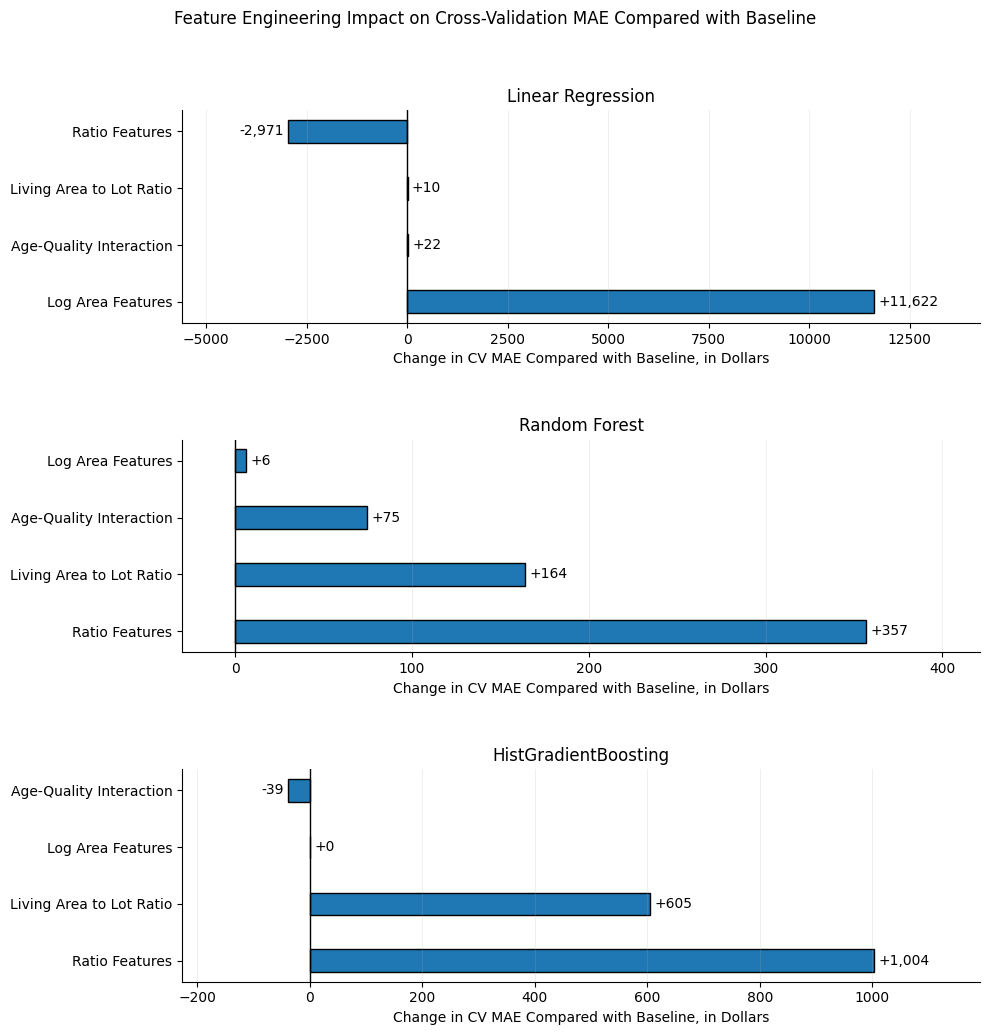

Figure 1 shows how each feature engineering experiment changed the cross-validation MAE compared with the baseline version of the same model. Negative values indicate lower MAE and better performance, while positive values indicate higher MAE and worse performance.

The effect of feature engineering depended on the type of model. For Linear Regression, the ratio features reduced MAE by about 2,971 dollars. However, the log-transformed area features increased MAE by about 11,622 dollars. The age-quality interaction and living-area-to-lot ratio produced almost no change.

For HistGradientBoosting, the age-quality interaction improved MAE by only about 39 dollars, while the log area features produced almost no change. The living-area-to-lot ratio and the combined ratio features made the model worse.

None of the new feature engineering experiments improved Random Forest. The log area features produced almost the same result as the baseline, while the other experiments increased MAE by approximately 75 to 357 dollars.

Because Random Forest was the strongest model and none of the new experiments improved its validation performance, these Milestone 2 features were not included in the final Random Forest. The `property_age` feature, which had been created earlier during data preparation, was still retained.

#### **Random Forest Feature Selection**

Next, Random Forest feature importance was examined to identify the most useful predictors and select a smaller feature set.

**Figure 2. Top 20 Random Forest Feature Importances**

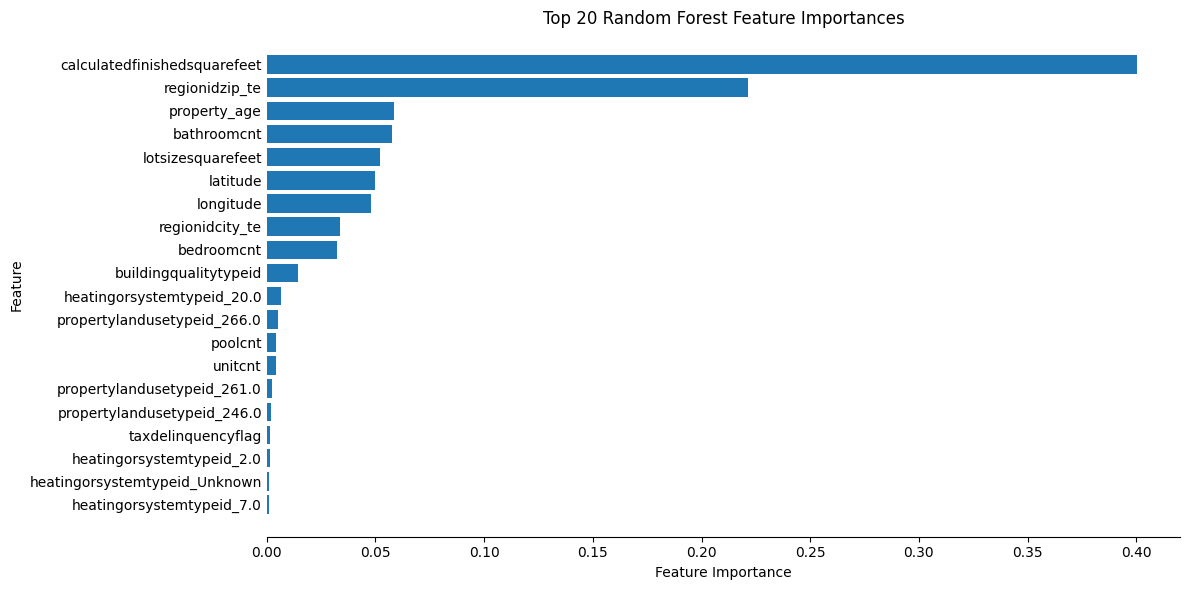

Figure 2 shows the 20 features with the highest importance scores in the Random Forest. The importance was concentrated in a small number of features. Finished living area and ZIP code together accounted for 62.17 percent of the total importance. Property age, bathroom count, lot size, latitude, longitude, city, and bedroom count were also among the main predictors.

**Table 1. Complete Random Forest Feature Importance Ranking**  

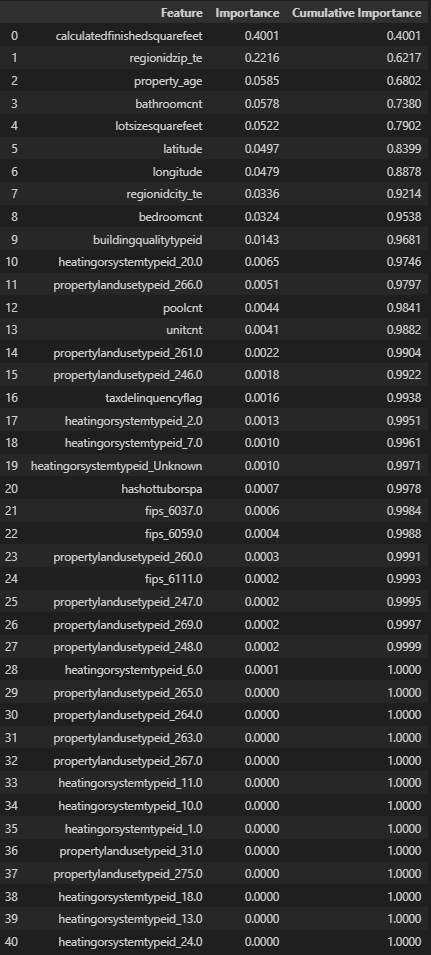

Table 1 shows the complete ranking of all 41 features and supports the selection of the top 20. By the twentieth feature, cumulative importance had reached 99.71 percent. The remaining 21 features together accounted for only 0.29 percent. Their individual importance values were very small, and the final 12 features were displayed as 0.0000 after rounding to four decimal places.

Using the top 20 features also kept nearly the same validation performance. The mean CV MAE was about 188,554 dollars with all 41 features and about 188,560 dollars with the top 20 features. This difference was very small compared with the overall prediction error.

For this reason, the top 20 features were kept. They contained nearly all of the measured feature importance while reducing the number of inputs by more than half. The remaining features added very little predictive value. This made the final model simpler, more focused, and easier to understand without a meaningful loss in validation performance.

The importance scores represent predictive usefulness within the Random Forest model. They do not prove that a feature directly causes a change in property value.

#### **Hyperparameter Search Comparison**

After feature selection, the two strongest tree-based models were tuned to improve validation performance and better control model complexity. Focused sweeps were first used to test one hyperparameter at a time and find useful ranges. RandomizedSearchCV was then used to test different combinations within those ranges.

**Table 2. Hyperparameter Tuning Results**

| Model | Baseline Mean CV MAE | Focused Sweeps Mean CV MAE | Randomized Search Mean CV MAE | Final Choice |
|---|---:|---:|---:|---|
| Random Forest | 188,554 | 184,633 | 184,641 | Focused Sweeps |
| HistGradientBoosting | 191,286 | 188,522 | 188,100 | Randomized Search |

The final candidates were compared using the same repeated 5-fold cross-validation with 5 repeats. This provided a consistent way to compare the two tuning methods.

For Random Forest, `max_features` had the largest effect on validation performance. Using fewer features at each split lowered the CV MAE. The `max_depth` and `min_samples_leaf` settings were also useful for controlling the complexity of the trees. Changes to `min_samples_split` and `n_estimators` had smaller effects after the results became stable.

The focused-sweep and Randomized Search results for Random Forest were almost the same. The focused-sweep model had a slightly lower mean CV MAE, so its settings were kept. The selected Random Forest used 900 trees, a maximum depth of 20, 4 features at each split, a minimum of 8 samples to split a node, and a minimum of 2 samples in each leaf.

For HistGradientBoosting, `max_leaf_nodes` had the clearest effect, followed by `min_samples_leaf`. These settings controlled how detailed the model could become. Changes to `max_features` had a smaller effect, while changing `max_iter` or `max_depth` alone did not improve the validation result. Randomized Search produced the lower CV MAE for this model, so its settings were kept.

Linear Regression is not included in this table because it was improved through feature engineering and feature subset selection rather than focused sweeps and Randomized Search.

Overall, tuning improved both tree-based models. Random Forest had the lower tuning-stage validation MAE, while Randomized Search produced the better result for HistGradientBoosting.

*The values in Table 2 are the tuning-stage results. The complete final Random Forest pipeline, including preprocessing and feature selection, was evaluated separately in Section 5.1.*

#### **Overall Evidence**

Together, these results show how the final model was developed. The new feature engineering ideas were tested but were not kept because they did not improve Random Forest performance. Feature selection reduced the number of inputs from 41 to 20 while keeping nearly the same validation performance, making the model simpler and easier to understand. Finally, hyperparameter tuning improved the tree-based models, and the tuned Random Forest produced the best validation result and was selected as the final model.
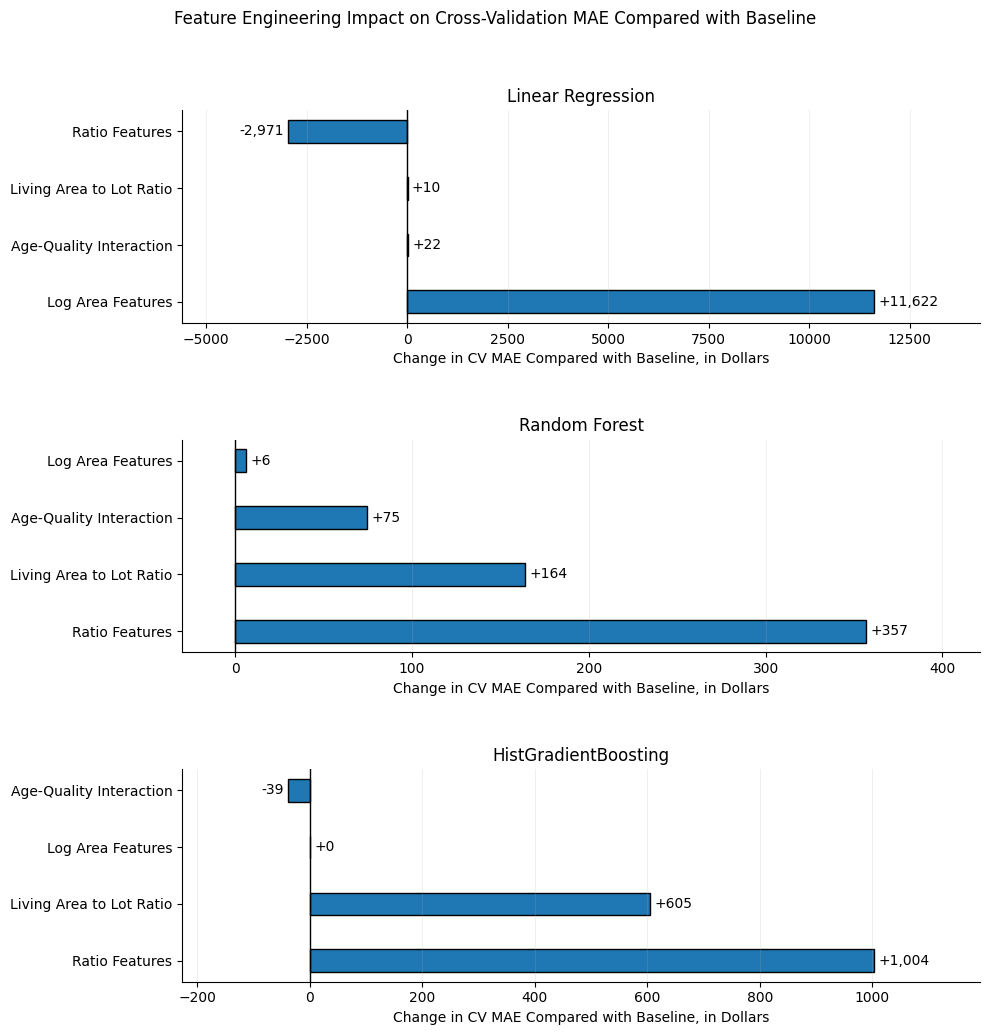
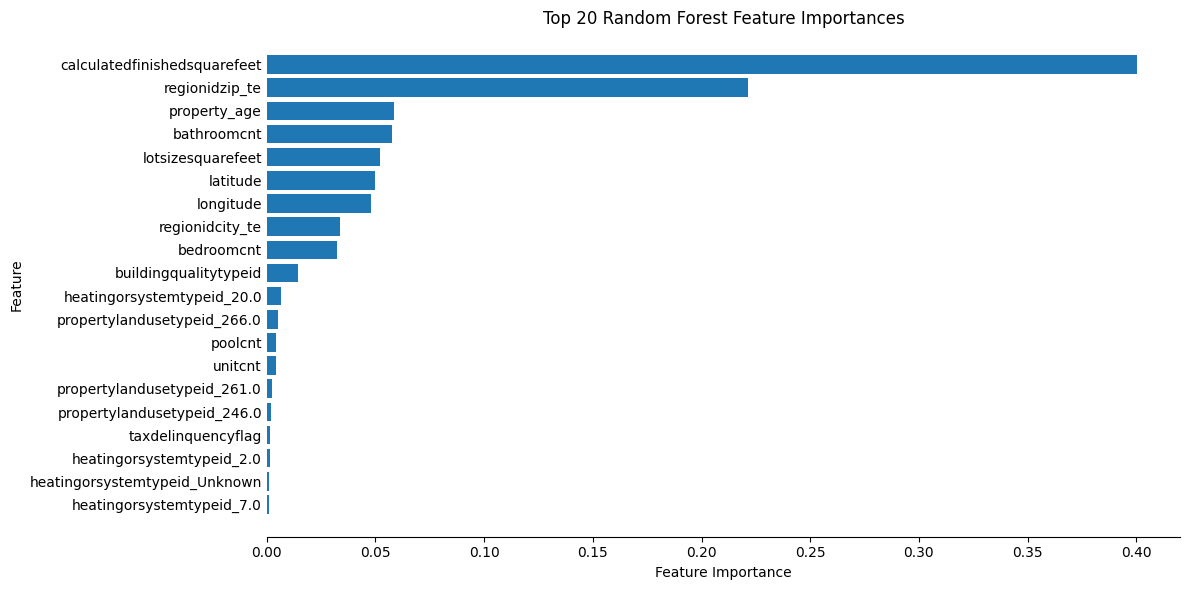

### 5.3 Model Limitations (2 points)

Discuss the most important limitations or weaknesses of your final model.

Base your discussion on the results and analyses completed in Milestone 2. You are not required to conduct new modeling experiments for this section, although you may include an additional numerical summary or visualization if it helps clarify your conclusions.

Include, as appropriate:

- evidence of underfitting, overfitting, instability, or differences among - training, validation, and test performance,
- types of observations or properties that may be especially difficult to predict,
- plausible explanations for the model’s limitations, and
- one or more potential changes that might improve future performance.

Focus on interpreting the model’s limitations rather than merely restating its performance metrics.

**5.3 Answer:**  

The final Random Forest gave similar results on the validation and test data, but it still has some limits.

First, some overfitting is still present. The training MAE was about 144,746 dollars, while the mean cross-validation MAE was about 184,959 dollars. This gap was much smaller than in the original Random Forest (Baseline model), so tuning helped reduce overfitting. However, the model still performs better on the training data than on new data.

The model was fairly stable across the cross-validation folds. The CV MAE standard deviation was about 2,883 dollars, and the test MAE of about 185,580 dollars was close to the mean CV MAE. This shows that the model gave consistent results. However, the average error was still high. A difference of about 185,580 dollars may be too large when an accurate estimate is needed for one property.

Some properties may also be harder to predict. The target value and several size-related features were strongly right-skewed and included large outliers. For this reason, unusual or very expensive properties may be more difficult for the model. Rare property types and locations with fewer examples may also be harder to predict. These groups were not tested separately, so more error analysis would be needed to confirm this.

Another limitation is the information available in the dataset. Many columns had large amounts of missing data, so some property details could not be used. ZIP code and city were useful, but they may not fully capture small differences between nearby areas. Other useful information, such as recent renovations, property condition, school quality, or distance from important places, was also not available.

Future work could compare errors across property-value ranges, ZIP codes, cities, and property types. This would help show where the model performs well and where it has larger errors. More detailed location features and more complete property information may also improve performance. Other models, such as CatBoost, could also be tested because they can work directly with categorical features.

## 6. Conclusion [4 points]

Summarize the main findings and implications of your analysis. This section should not simply repeat the Executive Summary. It is written for a technical audience that has read the full report and should synthesize the evidence, limitations, and practical significance of your work.

Include all of the following:

* clearly state your main findings and explain how they address the original project objectives,
* highlight the business or practical implications of those findings,
* discuss the limitations and constraints of your analysis clearly and transparently,
* suggest potential improvements or directions for future work, and
* conclude with a final recommendation that addresses the original business objective.


**6.1 Answer:**  

This project had two main goals: to understand which property features were useful for predicting assessed tax value and to build a regression model that could make reliable predictions on unseen data. The final tuned Random Forest met these goals better than Linear Regression and HistGradientBoosting. It produced the lowest validation error, with a mean cross-validation MAE of about 184,959 dollars. Its test MAE was about 185,580 dollars, which was very close to the validation result. This shows that the model’s performance was consistent when it was applied to new data.

The analysis also identified the property information that was most useful for prediction. Finished living area and ZIP code had the highest Random Forest importance scores. Property age, bathroom count, lot size, latitude, longitude, city, and bedroom count were also useful. These results show that both the physical features of a property and its location are important when estimating assessed tax value. However, these importance scores describe predictive value within the model and should not be treated as proof that a feature directly causes a higher or lower assessment.

The model-development process also led to several important findings. The additional feature engineering ideas did not improve the final Random Forest, even when they seemed reasonable based on the earlier data analysis. This showed that useful feature engineering depends on the model being used. Feature selection reduced the number of inputs from 41 to 20 while keeping nearly the same validation performance. Hyperparameter tuning produced the largest performance improvement and greatly reduced the gap between training and validation error. These results also showed why model decisions should be based on cross-validation rather than training performance alone.

From a practical point of view, the final model could help a real estate company study assessed value patterns across a large group of properties. It could provide an estimated value, support comparisons between similar properties, or help identify records that may need further review. However, the target in this project was assessed tax value, not market sale price. The model should therefore not be used as a direct estimate of what a property would sell for. It should also not replace a professional review when an accurate estimate is needed for a single property.

The model still has important limits. Its average test error of about 185,580 dollars is large for decisions that require a precise property-level estimate. Some overfitting also remains because the training MAE was lower than the validation and test MAE. Expensive properties, unusual homes, rare property types, and locations with fewer examples may be especially difficult to predict. The data also contained many missing values, and some useful details were not available. Features such as recent renovations, detailed property condition, school quality, and smaller neighborhood differences could help explain property values but were not included in the dataset.

Future work should begin with a more detailed error analysis. Prediction errors could be compared across value ranges, ZIP codes, cities, and property types to find where the model works well and where it has larger errors. More detailed geographic features, such as location clusters, grid areas, or distance-based features, could improve the representation of local housing markets. More complete property data could also improve performance. Other models, such as CatBoost, could be tested, and permutation importance or SHAP values could provide a clearer explanation of individual predictions.

The final recommendation is to use the tuned Random Forest as a supporting tool for estimating and studying assessed property values across many records. It provides the best balance of predictive performance, stability, and model simplicity among the models tested. However, because the remaining error is still meaningful, its predictions should be combined with additional property information and human review rather than used as the only basis for important property-level decisions.